<a href="https://colab.research.google.com/github/sjkim-audio/Bass-separator/blob/main/notebooks/transcription/07_src_test_phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# ==================================================================
# [Bass Separator] Universal Environment Setup (v3.0 - Robust Edition)
# ==================================================================
import os
import sys
import subprocess
from google.colab import drive

# -----------------------------------------------------------------
# 0. Auto-Reload Setup (GitHub 코드 업데이트 즉시 반영용)
# -----------------------------------------------------------------
# The 'imp' module, used by autoreload, was removed in Python 3.12. Commenting out.
# from IPython import get_ipython
# ipython = get_ipython()
# if ipython is not None:
#     ipython.magic("load_ext autoreload")
#     ipython.magic("autoreload 2")
#     print("🔄 Auto-reload enabled. (Code changes will apply immediately)")

# -----------------------------------------------------------------
# 1. Google Drive Mount & Project Path Setup
# -----------------------------------------------------------------
# 이미 마운트된 경우 불필요한 재실행 에러 방지
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

PROJECT_NAME = "Bass-separator"
REPO_URL = "https://github.com/sjkim-audio/Bass-separator.git"  # 본인 깃허브 URL로 변경 확인
PROJECT_PATH = f"/content/{PROJECT_NAME}"

# Clone or Hard-Reset Repository (Colab 로컬 찌꺼기 무시, 무조건 최신화)
try:
    if not os.path.exists(PROJECT_PATH):
        print(f"📦 Cloning repository... ({PROJECT_NAME})")
        subprocess.run(["git", "clone", REPO_URL], check=True)
    else:
        print(f"🔄 Updating repository... (Git Fetch & Reset)")
        subprocess.run(["git", "fetch", "--all"], cwd=PROJECT_PATH, check=True)
        # 메인 브랜치 이름이 'main'인지 'master'인지에 따라 아래 origin/main 수정 필요
        subprocess.run(["git", "reset", "--hard", "origin/main"], cwd=PROJECT_PATH, check=True)
except subprocess.CalledProcessError as e:
    raise RuntimeError(f"❌ Git repository sync failed: {e}")

# Set Working Directory
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)
os.chdir(PROJECT_PATH)
print(f"📂 Working Directory set to: {os.getcwd()}")

# -----------------------------------------------------------------
# 2. Initialize Environment using [src] modules
# -----------------------------------------------------------------
try:
    # 깃허브에서 동기화된 최신 모듈 임포트
    from src.env_setup import init_colab_env
    from src.utils import load_data_from_drive

    init_colab_env()

    MY_DRIVE_DATA_PATH = "/content/drive/MyDrive/Bass_separator/dataset"
    load_data_from_drive(MY_DRIVE_DATA_PATH)

except ImportError as e:
    print(f"⚠️ Error importing src modules: {e}\n   (경로나 파일명이 정확한지 확인하세요.)")
except Exception as e:
    print(f"❌ Setup failed: {e}")

# -----------------------------------------------------------------
# 3. Pre-load Common Libraries
# -----------------------------------------------------------------
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display

print("\n🚀 Ready to Rock! (Environment Setup Completed)")

🔄 Updating repository... (Git Fetch & Reset)
📂 Working Directory set to: /content/Bass-separator
⚠️ Error importing src modules: No module named 'shuti'
   (경로나 파일명이 정확한지 확인하세요.)

🚀 Ready to Rock! (Environment Setup Completed)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 5.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.1/249.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 5.5 MB/s eta 0:00:00
  Created wheel for demucs: filename=demucs-4.0.1-py3-none-any.whl size=78388 sha256=4def7dbfe192cca8fe9cf97f4ff10bf58e392667319a0dfa65b7035f8c40248f
  Stored in directory: /root/.cache/pip/wheels/1b/0c/20/a3b3daa1f9b65c8b0445729f94740ec335d0f86f1066c5c414
  Created wheel for julius: filename=julius-0.2.7-

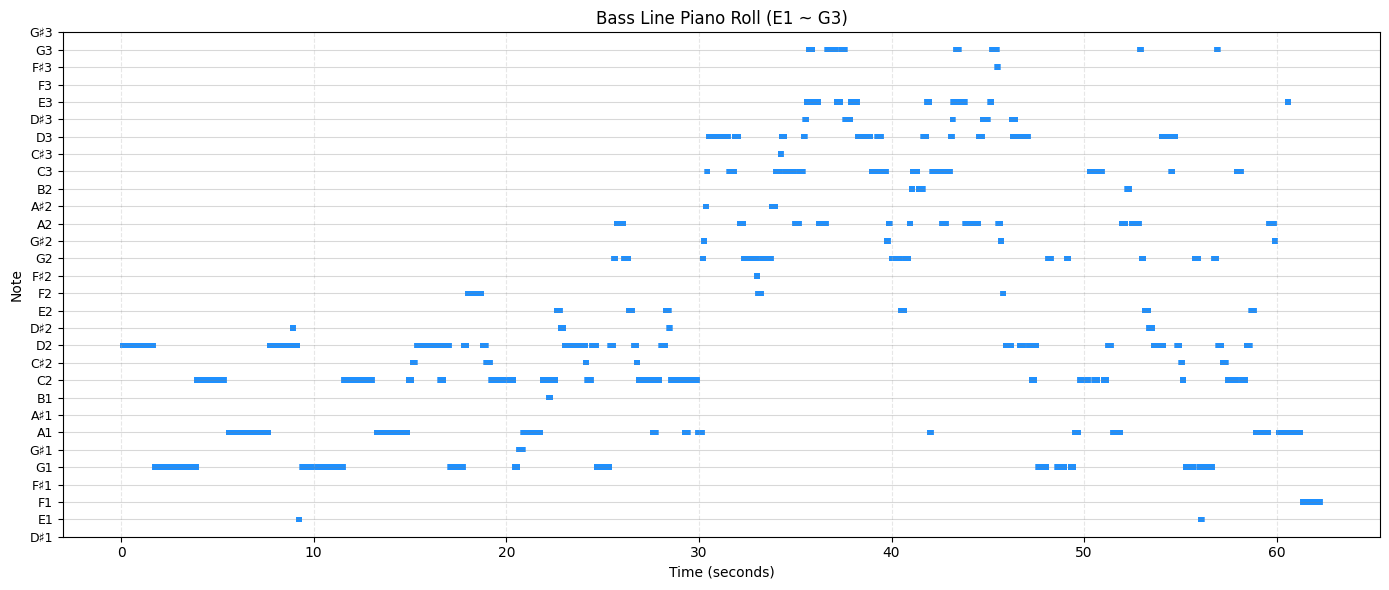

💾 Exporting MIDI...
💾 MIDI Saved: /content/drive/MyDrive/Bass_separator/performance_test_demo(guitar + bass)_bass_tab.mid
🎉 모든 처리가 완료되었습니다.
💾 최종 MIDI 저장 위치: /content/drive/MyDrive/Bass_separator/performance_test_demo(guitar + bass)_bass_tab.mid


In [9]:
import os
import sys
import subprocess
from pathlib import Path

# Install missing dependencies
!pip install torchcrepe
!pip install pretty_midi
!pip install demucs

# 1. 소스 코드는 깃허브 클론 디렉토리에서 참조
GITHUB_ROOT = "/content/Bass-separator"
if GITHUB_ROOT not in sys.path:
    sys.sys.path.append(GITHUB_ROOT)

# 깃허브 폴더 내부의 src 패키지에서 파이프라인 임포트
from src.bass_transcription import run_pipeline

def process_audio_to_tab(input_file):
    input_path = Path(input_file)
    if not input_path.exists():
        raise FileNotFoundError(f"❌ 파일을 찾을 수 없습니다: {input_path}")

    # Demucs 출력 설정 (Colab 로컬 스토리지 사용 - I/O 속도 향상)
    output_dir = Path("/content/separated_stems")
    model_name = "htdemucs"

    print(f"🎸 [Step 1] Demucs 2-Stem 분리 시작: {input_path.name}")

    demucs_cmd = [
        "demucs",
        "--two-stems=bass",
        "-n", model_name,
        "-o", str(output_dir),
        str(input_path)
    ]

    try:
        subprocess.run(demucs_cmd, check=True, capture_output=True, text=True)
    except subprocess.CalledProcessError as e:
        print("❌ Demucs 실행 중 오류가 발생했습니다.")
        print(f"[Error Log]\n{e.stderr}")
        return None

    track_name = input_path.stem
    bass_stem_path = output_dir / model_name / track_name / "bass.wav"

    if not bass_stem_path.exists():
        raise FileNotFoundError(f"❌ 베이스 분리 파일을 찾을 수 없습니다: {bass_stem_path}")

    print(f"✅ 베이스 분리 완료: {bass_stem_path}")
    print(f"🎼 [Step 2] 베이스 채보 파이프라인 시작...")

    # 2. 결과물(MIDI)은 데이터 유실 방지를 위해 구글 드라이브에 저장
    DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/Bass_separator"
    output_midi_path = f"{DRIVE_OUTPUT_DIR}/{track_name}_bass_tab.mid"

    # 채보 파이프라인 실행
    f0_result = run_pipeline(str(bass_stem_path), output_midi=output_midi_path)

    print("🎉 모든 처리가 완료되었습니다.")
    print(f"💾 최종 MIDI 저장 위치: {output_midi_path}")

    return f0_result

# ==========================================
# 실행부
# ==========================================
if __name__ == "__main__":
    # 데이터는 구글 드라이브에서 로드
    TARGET_AUDIO = "/content/drive/MyDrive/Bass_separator/dataset/performance_test_demo(guitar + bass).wav"

    f0_data = process_audio_to_tab(TARGET_AUDIO)